In [193]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import datetime
from utils.log import Logger
from utils.common import data_preprocessing
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib

In [194]:
class PowerLoadModel(object):
    def __init__(self, filename):
        logfile_name = "train_" + datetime.datetime.now().strftime('%Y%m%d%H%M%S')
        self.logfile = Logger('../', logfile_name).get_logger()
        self.data_source = data_preprocessing(filename)

In [195]:
def vis_data(data):
    data = data.copy()
    # data.info()
    fig = plt.figure(figsize=(20, 32))
    ax1 = fig.add_subplot(4, 1, 1)
    ax1.hist(data['power_load'], bins=100)
    ax1.set_title('power load histogram')

    ax2 = fig.add_subplot(4, 1, 2)
    data['hour'] = data['time'].str[11:13]
    data_hour_mean = data.groupby(by='hour', as_index=False)['power_load'].mean()
    ax2.plot(data_hour_mean['hour'], data_hour_mean['power_load'], c='b', linewidth=2)
    ax2.set_title('power load by hour')
    ax2.set_xlabel('hour')
    ax2.set_ylabel('power load')
    ax2.grid(alpha=0.5)

    ax3 = fig.add_subplot(4, 1, 3)
    data['month'] = data['time'].str[5:7]
    data_month_mean = data.groupby(by='month', as_index=False)['power_load'].mean()
    ax3.plot(data_month_mean['month'], data_month_mean['power_load'], c='r', linewidth=2)
    ax3.set_title('power load by month')
    ax3.set_xlabel('month')
    ax3.set_ylabel('power load')
    ax3.grid(alpha=0.5)

    ax4 = fig.add_subplot(4, 1, 4)
    data['weekday'] = data['time'].apply(lambda x: pd.to_datetime(x).weekday())
    data['is_weekday'] = data['weekday'].apply(lambda x: 1 if x < 5 else 0)
    data_weekday_mean = data[data['is_weekday'] == 1]['power_load'].mean()
    data_weekend_mean = data[data['is_weekday'] == 0]['power_load'].mean()
    ax4.bar(x=['weekday', 'weekend'], height=[data_weekday_mean, data_weekend_mean], color=['g', 'y'])
    ax4.set_title('power load by weekday/weekend')
    ax4.set_xlabel('day type')
    ax4.set_ylabel('power load')
    ax4.grid(alpha=0.5)


In [196]:
def feature_engineering(data, logger):
    result = data.copy(deep=True)

    # extract hour and month
    result['hour'] = result['time'].str[11:13]
    result['month'] = result['time'].str[5:7]
    hour_encoding = pd.get_dummies(result['hour'])
    hour_encoding.columns = ['hour_' + str(i) for i in hour_encoding.columns]
    month_encoding = pd.get_dummies(result['month'])
    month_encoding.columns = ['month_' + str(i) for i in month_encoding.columns]
    result = pd.concat([result, hour_encoding, month_encoding], axis=1)
    # result.info()

    # extract wnd features
    wnd_size = 3
    shift_lst = [result['power_load'].shift(i) for i in range(1, wnd_size + 1)]
    shift_data = pd.concat(shift_lst, axis=1)
    shift_data.columns = ['前' + str(i) + '小时' for i in range(1, wnd_size + 1)]
    result = pd.concat([result, shift_data], axis=1)

    # extract same hour features on the previous day
    time_load_dict = result.set_index('time')['power_load'].to_dict()
    result['yesterday_time'] = result['time'].apply(lambda x: (pd.to_datetime(x) - pd.to_timedelta('1D')).strftime('%Y-%m-%d %H:%M:%S'))
    result['yesterday_load'] = result['yesterday_time'].apply(lambda x: time_load_dict.get(x))
    result.dropna(axis=0, inplace=True)

    time_feature_names = list(hour_encoding.columns) + list(month_encoding.columns) + list(shift_data.columns) + ['yesterday_load']
    
    return result, time_feature_names




    


In [197]:
def model_train(data, features, logger):
    x = data[features]
    y = data['power_load']
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=23)

    # param_dict = {
    #     'n_estimators': [50, 100, 150, 200],
    #     'max_depth': [3, 6, 9],
    #     'learning_rate': [0.1, 0.01]

    # }

    # gs = GridSearchCV(estimator=XGBRegressor(), param_grid=param_dict, cv=5)
    # gs.fit(x_train, y_train)

    # print('best params:', gs.best_params_)  # {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

    estimator = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.1)
    estimator.fit(x_train, y_train)
    y_pred = estimator.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f'Mean Squared Error: {mse}')

    joblib.dump(estimator, '../model/xgb.pkl')

In [198]:
# train main

input_file = os.path.join('../data', 'train.csv')
model = PowerLoadModel(input_file)
# vis_data(model.data_source)
feature_data, feature_names = feature_engineering(model.data_source, model.logfile)
model_train(feature_data, feature_names, model.logfile)


Mean Squared Error: 6219.230921037386


In [199]:
class PowerLoadPredict(object):
    def __init__(self, filename):
        logfile_name = 'predict_' + datetime.datetime.now().strftime('%Y%m%d%H%M%S')
        self.logfile = Logger('../', logfile_name).get_logger()
        self.data_source = data_preprocessing(filename)
        self.data_dict = self.data_source.set_index('time')['power_load'].to_dict()

In [200]:
def pred_feature_engineering(data_dict, time, logger):
    feature_names = ['hour_00', 'hour_01', 'hour_02', 'hour_03', 'hour_04', 'hour_05',
                     'hour_06', 'hour_07', 'hour_08', 'hour_09', 'hour_10', 'hour_11',
                     'hour_12', 'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17',
                     'hour_18', 'hour_19', 'hour_20', 'hour_21', 'hour_22', 'hour_23',
                     'month_01', 'month_02', 'month_03', 'month_04', 'month_05', 'month_06',
                     'month_07', 'month_08', 'month_09', 'month_10', 'month_11', 'month_12',
                     '前1小时', '前2小时', '前3小时', 'yesterday_load']
    
    hour_onehot = []
    pred_hour = time[11:13]
    for i in range(24):
        if pred_hour == feature_names[i][5:7]: hour_onehot.append(1)
        else: hour_onehot.append(0)

    month_onehot = []
    pred_month = time[5:7]
    for i in range(24, 36):
        if pred_month == feature_names[i][6:8]: month_onehot.append(1)
        else: month_onehot.append(0)

    history_loads = []
    last_1_time = (pd.to_datetime(time) - pd.to_timedelta('1h')).strftime('%Y-%m-%d %H:%M:%S')
    last_1_load = data_dict.get(last_1_time, 600)  # 如果没有前1小时的负荷数据，默认设置为600

    last_2_time = (pd.to_datetime(time) - pd.to_timedelta('2h')).strftime('%Y-%m-%d %H:%M:%S')
    last_2_load = data_dict.get(last_2_time, 600)  

    last_3_time = (pd.to_datetime(time) - pd.to_timedelta('3h')).strftime('%Y-%m-%d %H:%M:%S')
    last_3_load = data_dict.get(last_3_time, 600)

    yesterday_time = (pd.to_datetime(time) - pd.to_timedelta('1D')).strftime('%Y-%m-%d %H:%M:%S')
    yesterday_load = data_dict.get(yesterday_time, 600)

    history_loads = [last_1_load, last_2_load, last_3_load, yesterday_load]
    feature_lst = [hour_onehot + month_onehot + history_loads]
    feature_df = pd.DataFrame(feature_lst, columns=feature_names)

    return feature_df, feature_names

In [201]:
def pred_plot(df):
    fig = plt.figure(figsize=(40, 20))
    ax = fig.add_subplot()
    ax.plot(df.time, df.true_load, label='true load', c='b')
    ax.plot(df.time, df.pred_load, label='pred load', c='r')
    ax.set_ylabel('power load')
    ax.set_title('true load vs pred load')
    ax.legend()
    ax.grid(alpha=0.5)
    ax.xaxis.set_major_locator(mtick.MultipleLocator(50))
    plt.xticks(rotation=45)
    plt.show()

Mean Absolute Error: 58.441034788726476


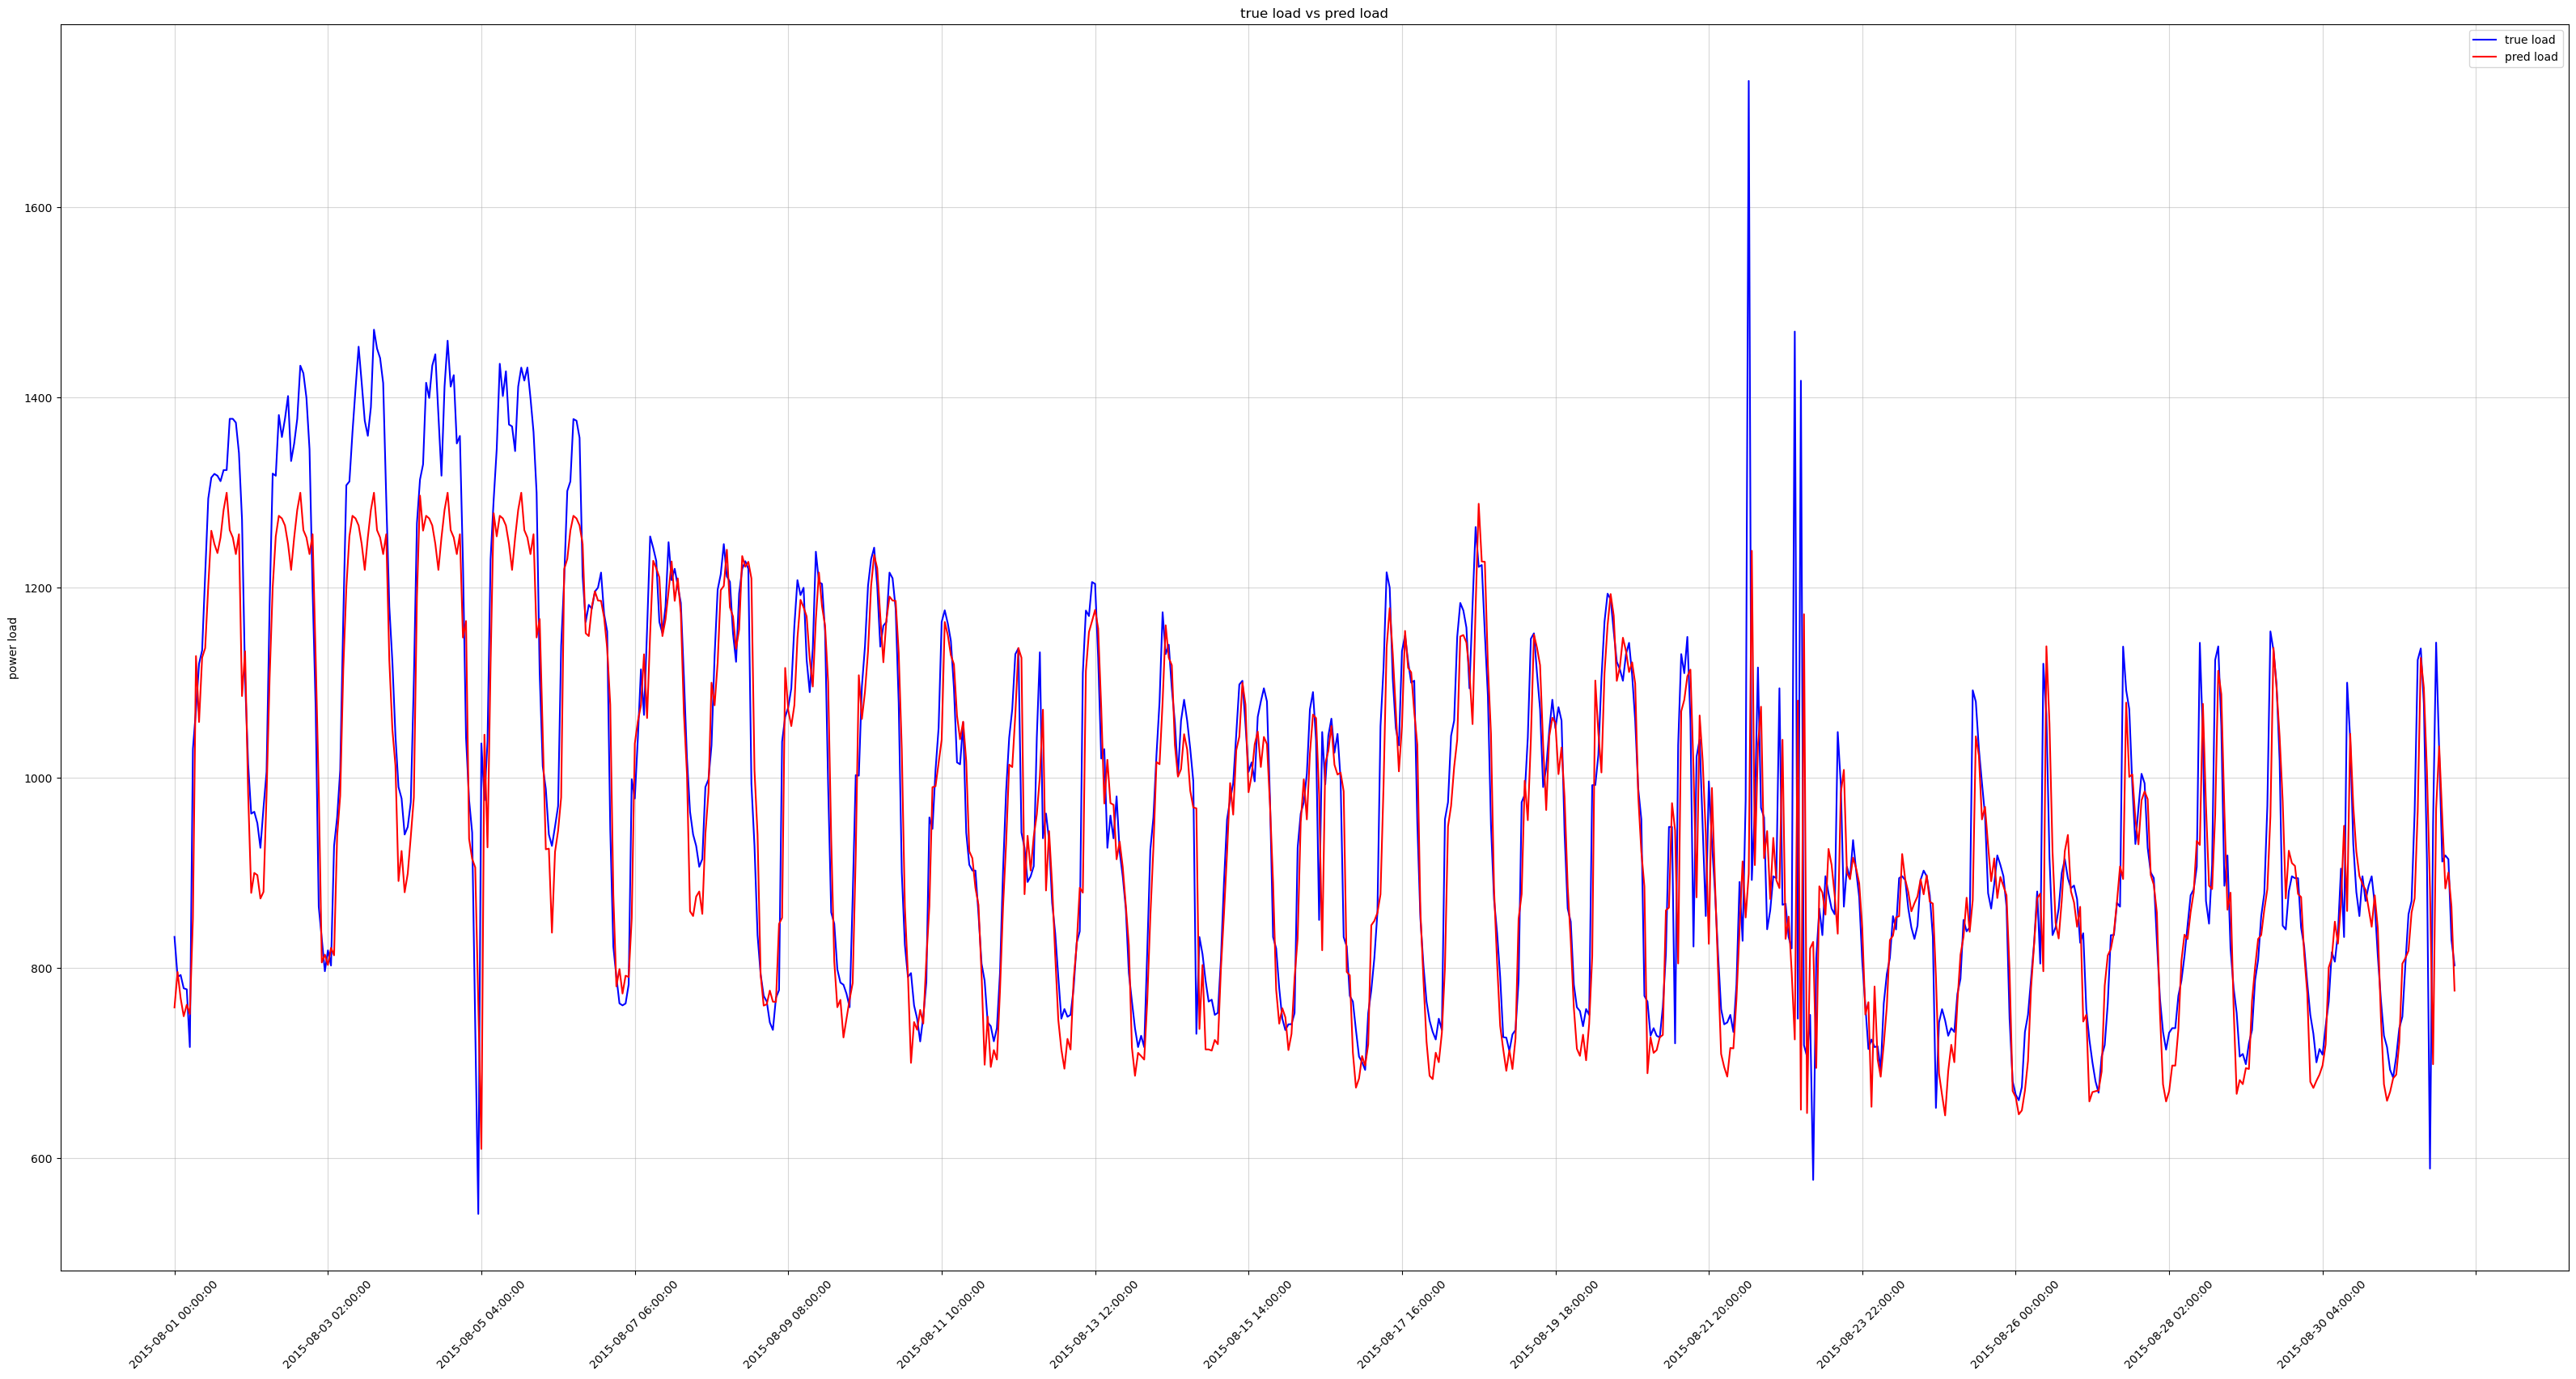

In [202]:
# predict main

pred_input_file = os.path.join('../data', 'test.csv')
predictor = PowerLoadPredict(pred_input_file)
estimator = joblib.load('../model/xgb.pkl')

eval_lst = []
pred_times = predictor.data_source[predictor.data_source['time'] >= '2015-08-01 00:00:00']['time']
for pred_time in pred_times:
    time_load_dict_masked = {k: v for k, v in predictor.data_dict.items() if k < pred_time}
    feature_df, feature_names = pred_feature_engineering(time_load_dict_masked, pred_time, predictor.logfile)

    y_pred = estimator.predict(feature_df)
    y_true = predictor.data_dict.get(pred_time)
    eval_lst.append([pred_time, y_true, y_pred[0]])

eval_df = pd.DataFrame(eval_lst, columns=['time', 'true_load', 'pred_load'])
mae = mean_absolute_error(eval_df['true_load'], eval_df['pred_load'])
print(f'Mean Absolute Error: {mae}')
pred_plot(eval_df)

